In [8]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.parameter_adaptation import cross_validated_parameter_adaptation
from non_parametric_pro.util import run_inference_algorithm_with_burn_in
from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler

jax.config.update("jax_enable_x64", True)

In [22]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset("autompg", split=2)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(example.x_train)
y_train = scaler_y.fit_transform(example.y_train)

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [23]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
lengthscale = gpx.parameters.SigmoidBounded(
    jnp.sqrt(D) * jnp.ones((D,)), low=1.0e-3, high=1.0e3
)
kernel = gpx.kernels.RBF(lengthscale=lengthscale, variance=px.NonTrainable(jnp.array(1.0)))

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n, obs_stddev=jnp.sqrt(0.01))
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
)

gp_latent_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = float(px.unwrap(gp_posterior.likelihood.obs_stddev))
gp_kernel = gp_posterior.prior.kernel

print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_mean, gp_predictive_std))

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))
print("GP sigma", gp_sigma)

Optimization terminated successfully.
         Current function value: 123.861257
         Iterations: 51
         Function evaluations: 57
         Gradient evaluations: 57
GP Train NLPD: 0.19229039464782544
GP Test NLPD: 0.3174978300278625
GP sigma 0.3078111787799941


In [52]:
num_particles = 50
sigma = gpx.parameters.SigmoidBounded(gp_sigma, low=0.1, high=gp_sigma+0.01)

pro_kernel = gp_kernel
k = pro_kernel.gram(x_train).as_matrix()
basis_full = jnp.linalg.cholesky(k + 1e-6 * jnp.eye(k.shape[0]))

pro_params = ProParameters(
    y=y_train,
    basis=basis_full,
    step_size=1e-4,
    sigma=0.18,
    alpha=0.5,
)

In [53]:
algorithm = parametric_ula(pro_logdensity_fn, pro_params)
num_steps = 15000

key, pos_key = jr.split(key)
initial_position = jr.normal(pos_key, (x_train.shape[0], num_particles))

key, sample_key = jr.split(key)
_, (states, info) = run_inference_algorithm(
    rng_key=sample_key,
    inference_algorithm=algorithm,
    initial_position=initial_position,
    num_steps=num_steps,
    progress_bar=True,
)

<div><progress max="15000" value="15000"></progress> 100.00% [15000/15000 00:00&lt;?]</div>

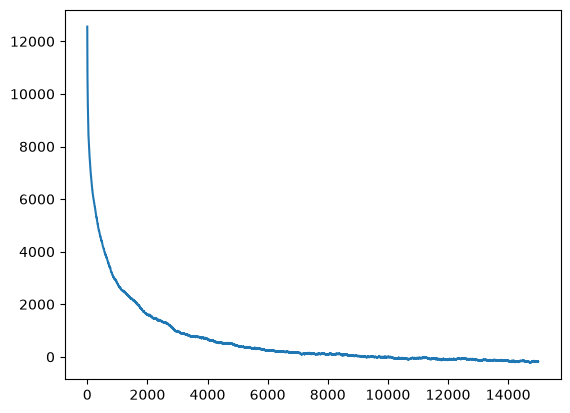

In [54]:
plt.plot(-info.score)
plt.show()

In [55]:
particles = states.position[12000::50]

test_basis, test_cov = prediction_basis(
    pro_kernel, x_train, x_train, pro_params
)

print("PRO Train NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params))

test_basis, test_cov = prediction_basis(
    pro_kernel, x_train, x_test, pro_params
)

print("PRO Test NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO Train NLPD: -0.018167294397112534
PRO Test NLPD: 0.16676397316365105
GP Test NLPD: 0.3174978300278625
